# Install and import packages

In [1]:
!pip install --upgrade seaborn
!pip install plotly

  Using cached plotly-6.5.0-py3-none-any.whl.metadata (8.5 kB)
Using cached plotly-6.5.0-py3-none-any.whl (9.9 MB)


In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns
import os

# Utils and Global variables

In [3]:
# Load original dataset
data_original = pd.read_csv('./datasets/vehicle_2_47174e+18.csv')

In [4]:
# Load synthetic dataset
epoch = 1200
synthetic_data = pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin2/windows_size_20/Generated_data/epoch_{epoch}/EV_generated_data_{epoch}.csv')

In [5]:
# Set SAVE equals to True, in order to Save cleaned data
SAVE = False

if SAVE:
    output_dir = f'./Data_saved/kl_scheduling/allRows_vin2/windows_size_20/'
    
    file_trip_path_csv = os.path.join(output_dir, f'EV_generated_data__trip_cleaned.csv')
    file_charge_path_csv = os.path.join(output_dir, f'EV_generated_data__charge_cleaned.csv')
    file_cleaned_path_csv = os.path.join(output_dir, f'EV_generated_data_cleaned.csv')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

In [6]:
# Set REASSIGN_CHARGE_MODE to True, in order to have a similar behavior with the original dataset for charge_mode feature
REASSIGN_CHARGE_MODE = True

In [7]:
# ===============================
# Threshold Configuration
# ===============================

# --- Discharge thresholds ---
MAX_DISCHARGE_PER_KM = 0.9    # Maximum allowable battery discharge per km
MIN_DISCHARGE_PER_KM = -1.0   # Minimum (negative) discharge per km

# --- Distance per discharge thresholds ---
MAX_KM_PER_DISCHARGE = 20     # Max km possible per discharge unit
MIN_KM_PER_DISCHARGE = -10    # Min km per discharge unit (negative edge case)

# --- Charging thresholds ---
MAX_CHARGE_PER_MIN = 1.10     # Maximum acceptable charge per minute
MIN_CHARGE_PER_MIN = 0.005    # Minimum acceptable charge per minute


# --- Speed threshold ---
SPEED_THRESHOLD = 130         # Max speed before flagging over-speed conditions


# Original dataset

## Trip data original

In [8]:
#trip_ data
trip_data_original = data_original[data_original['event'] == 'trip'].reset_index(drop=True)
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1207 entries, 0 to 1206
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          1207 non-null   float64
 1   timestamp    1207 non-null   object 
 2   end_time     1207 non-null   object 
 3   odo          1207 non-null   float64
 4   end_odo      1207 non-null   float64
 5   soc          1207 non-null   float64
 6   end_soc      1207 non-null   float64
 7   event        1207 non-null   object 
 8   charge_mode  1207 non-null   object 
dtypes: float64(5), object(4)
memory usage: 85.0+ KB


In [9]:
# Remove duplicates
trip_data_original = trip_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data_original)}")

trip_data_original['km_driven'] = trip_data_original['end_odo'] - trip_data_original['odo']
trip_data_original['discharge'] = trip_data_original['soc'] - trip_data_original['end_soc']

print("Statistics on driven km:\n", trip_data_original['km_driven'].describe())
print("\nStatistics on discharge:\n", trip_data_original['discharge'].describe())

Number of rows after removing duplicates: 1134
Statistics on driven km:
 count    1134.000000
mean       41.036223
std        46.765638
min         0.000000
25%         8.171871
50%        20.304685
75%        64.996092
max       378.187500
Name: km_driven, dtype: float64

Statistics on discharge:
 count    1134.000000
mean        7.874339
std         9.234552
min        -0.400000
25%         1.200000
50%         3.600000
75%        12.900000
max        74.600000
Name: discharge, dtype: float64


In [10]:
trip_data_original['km_per_perc_of_battery'] = trip_data_original.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data_original['discharge_per_km'] = trip_data_original.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

In [11]:
anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 7


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
16,-2.471740e+18,2021-04-29 19:05:00,2021-04-29 19:16:00,2419.812500,2419.84375,25.8,25.4,trip,0,0.031250,0.4,0.078125,12.800000
33,-2.471740e+18,2021-05-02 16:11:00,2021-05-02 16:53:00,2609.625000,2609.65625,34.1,33.3,trip,0,0.031250,0.8,0.039062,25.600000
55,-2.471740e+18,2021-05-05 17:40:00,2021-05-05 18:48:00,2875.703125,2875.75000,39.6,38.8,trip,0,0.046875,0.8,0.058594,17.066667
269,-2.471740e+18,2021-06-08 18:54:00,2021-06-08 18:56:00,11825.156250,11825.65625,50.5,49.8,trip,0,0.500000,0.7,0.714286,1.400000
446,-2.471740e+18,2021-07-11 19:53:00,2021-07-11 20:06:00,21003.656250,21009.34375,62.0,54.0,trip,0,5.687500,8.0,0.710938,1.406593
512,-2.471740e+18,2021-07-17 23:55:00,2021-07-18 01:05:00,23272.312500,23272.64063,41.9,39.2,trip,0,0.328130,2.7,0.121530,8.228446
788,-2.471740e+18,2021-08-10 15:06:00,2021-08-10 15:08:00,31879.125000,31879.32813,36.0,35.6,trip,0,0.203130,0.4,0.507825,1.969182


In [12]:
anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] < MIN_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] < MIN_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 0


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km


In [13]:
# Identify anomalous records with high km per percentage of battery discharge 
anomalous_discharge_records = trip_data_original[trip_data_original['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


trip_data_original = trip_data_original[~(trip_data_original['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE)].reset_index(drop=True)
anomalous_discharge_records.head(len(anomalous_discharge_records))

Number of anomalous discharge records: 3


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
535,-2.471740e+18,2021-07-23 00:31:00,2021-07-23 01:14:00,25236.45313,25248.85123,60.0,59.6,trip,0,12.3981,0.4,30.99525,0.032263
596,-2.471740e+18,2021-07-29 20:46:00,2021-07-29 21:00:00,27163.21875,27172.03125,15.2,14.9,trip,0,8.8125,0.3,29.37500,0.034043
521,-2.471740e+18,2021-07-13 00:08:00,2021-07-13 00:21:00,21541.39063,21550.70313,47.8,47.4,trip,0,9.3125,0.4,23.28125,0.042953


In [14]:
# Identify anomalous records with low km per percentage of battery discharge 
anomalous_discharge_records = trip_data_original[trip_data_original['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


trip_data_original = trip_data_original[~(trip_data_original['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE)].reset_index(drop=True)
anomalous_discharge_records.head(len(anomalous_discharge_records))

Number of anomalous discharge records: 0


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km


In [15]:
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vin                     1124 non-null   float64
 1   timestamp               1124 non-null   object 
 2   end_time                1124 non-null   object 
 3   odo                     1124 non-null   float64
 4   end_odo                 1124 non-null   float64
 5   soc                     1124 non-null   float64
 6   end_soc                 1124 non-null   float64
 7   event                   1124 non-null   object 
 8   charge_mode             1124 non-null   object 
 9   km_driven               1124 non-null   float64
 10  discharge               1124 non-null   float64
 11  km_per_perc_of_battery  1124 non-null   float64
 12  discharge_per_km        1124 non-null   float64
dtypes: float64(9), object(4)
memory usage: 114.3+ KB


In [16]:
trip_data_original['discharge_per_km'].describe()

count    1124.000000
mean        0.171832
std         0.081194
min        -0.474074
25%         0.151802
50%         0.182523
75%         0.205293
max         0.752941
Name: discharge_per_km, dtype: float64

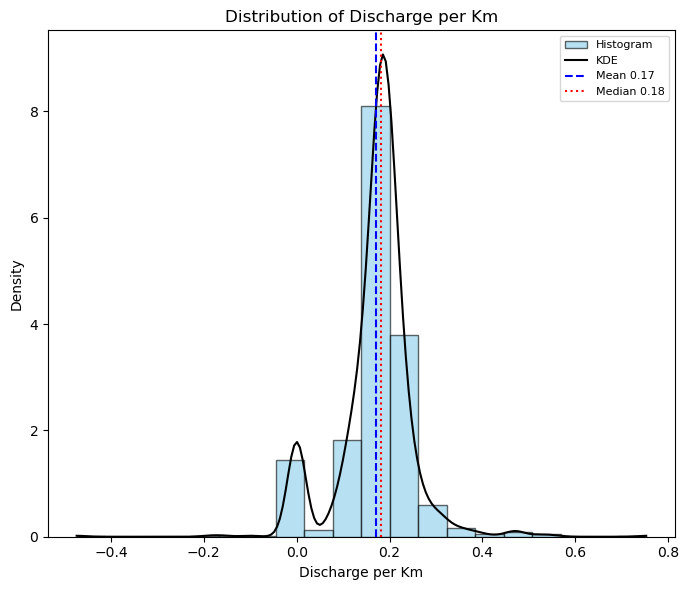

In [17]:
# Function that plot histogram and density of feature values provided
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20, density=True):
    """Plots histogram + KDE + mean & median, using DENSITY (not frequency)."""
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return

    # Histogram as DENSITY
    counts, bin_edges, _ = ax.hist(
        y, bins=bins, density=density, alpha=0.6,
        color=color, edgecolor='black', label='Histogram'
    )

    # KDE on density scale
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        kde_vals = kde(x_grid)
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass

    # Mean & median lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'Mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'Median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# --- Distribution of Discharge per Km ---
fig, ax = plt.subplots(figsize=(7, 6))

plot_hist_with_kde(trip_data_original.get('discharge_per_km', pd.Series(dtype=float)), ax,
                   color='skyblue', title='Distribution of Discharge per Km', xlabel='Discharge per Km')


plt.tight_layout()
plt.show()

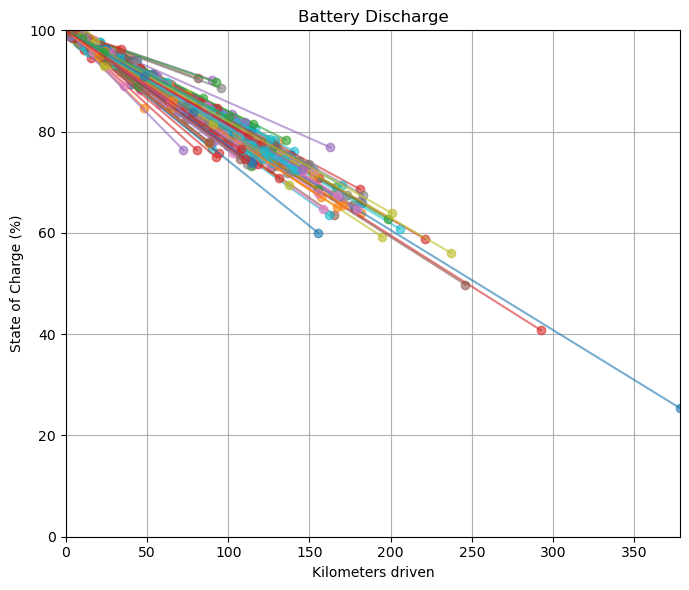

In [18]:
#visualize delta_soc
trip_data_original['delta_soc'] = trip_data_original['end_soc'] - trip_data_original['soc']
trip_data_original['soc'] = 100
trip_data_original['end_soc'] = trip_data_original['soc'] + trip_data_original['delta_soc'] 



# Max km for x-axis scaling
max_km_driven = trip_data_original['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data_original.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data_original.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


## Charge data original

In [19]:
charge_data_original = data_original[data_original['event'] == 'charge'].reset_index(drop=True)
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          543 non-null    float64
 1   timestamp    543 non-null    object 
 2   end_time     543 non-null    object 
 3   odo          543 non-null    float64
 4   end_odo      543 non-null    float64
 5   soc          543 non-null    float64
 6   end_soc      543 non-null    float64
 7   event        543 non-null    object 
 8   charge_mode  543 non-null    object 
dtypes: float64(5), object(4)
memory usage: 38.3+ KB


In [20]:
# Count number of entries for each charge_mode
counts = charge_data_original['charge_mode'].value_counts()
print(counts)

charge_mode
120           249
DCCharging    214
240            72
0               8
Name: count, dtype: int64


In [21]:
# Remove duplicates
charge_data_original = charge_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(charge_data_original)}")

charge_data_original['charge'] = charge_data_original['end_soc'] - charge_data_original['soc']
charge_data_original['discharge'] = charge_data_original['soc'] - charge_data_original['end_soc']

# Convert timestamps to datetime
charge_data_original['timestamp'] = pd.to_datetime(charge_data_original['timestamp'], errors='coerce')
charge_data_original['end_time'] = pd.to_datetime(charge_data_original['end_time'], errors='coerce')

# Compute event duration in minutes
charge_data_original['duration_minutes'] = (charge_data_original['end_time'] - charge_data_original['timestamp']).dt.total_seconds() / 60

print("\nStatistics on Charge:\n", charge_data_original['charge'].describe())

Number of rows after removing duplicates: 516

Statistics on Charge:
 count    516.000000
mean      17.133527
std       13.898268
min        0.300000
25%        3.175000
50%       13.950000
75%       29.400000
max       65.100000
Name: charge, dtype: float64


In [22]:
charge_data_original['min_per_perc_of_battery'] = charge_data_original.apply(
    lambda row: row['duration_minutes'] / -row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

charge_data_original['charge_per_min'] = charge_data_original.apply(
    lambda row: -row['discharge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)

In [23]:
anomalous_rows_charge = charge_data_original[(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)]
print(f"Number of anamalous rows: {anomalous_rows_charge.shape[0]}")

charge_data_original = charge_data_original[~(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)].reset_index(drop=True)
anomalous_rows_charge.head(len(anomalous_rows_charge ))

Number of anamalous rows: 12


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,charge,discharge,duration_minutes,min_per_perc_of_battery,charge_per_min
0,-2.471740e+18,2021-04-29 10:46:00,2021-04-29 11:17:00,2286.71875,2286.734375,24.3,59.2,charge,DCCharging,34.9,-34.9,31.0,0.888252,1.125806
112,-2.471740e+18,2021-06-07 22:55:00,2021-06-07 23:26:00,11661.75000,11661.750000,29.8,65.0,charge,DCCharging,35.2,-35.2,31.0,0.880682,1.135484
155,-2.471740e+18,2021-06-19 00:21:00,2021-06-19 00:51:00,15289.43750,15289.437500,29.8,64.3,charge,DCCharging,34.5,-34.5,30.0,0.869565,1.150000
223,-2.471740e+18,2021-07-15 20:12:00,2021-07-15 20:27:00,22365.68750,22365.687500,28.2,44.7,charge,DCCharging,16.5,-16.5,15.0,0.909091,1.100000
387,-2.471740e+18,2021-08-17 19:52:00,2021-08-17 20:09:00,34609.67188,34609.671880,29.8,50.9,charge,DCCharging,21.1,-21.1,17.0,0.805687,1.241176
390,-2.471740e+18,2021-08-18 13:57:00,2021-08-18 14:28:00,34909.48438,34909.484380,37.2,72.5,charge,DCCharging,35.3,-35.3,31.0,0.878187,1.138710
391,-2.471740e+18,2021-08-18 21:29:00,2021-08-18 22:04:00,35093.70313,35093.703130,37.2,76.8,charge,DCCharging,39.6,-39.6,35.0,0.883838,1.131429
394,-2.471740e+18,2021-08-19 15:57:00,2021-08-19 16:15:00,35501.14063,35501.140630,43.1,63.1,charge,DCCharging,20.0,-20.0,18.0,0.900000,1.111111
413,-2.471740e+18,2021-08-25 16:29:00,2021-08-25 16:41:00,37669.50000,37669.500000,30.9,48.6,charge,DCCharging,17.7,-17.7,12.0,0.677966,1.475000
453,-2.471740e+18,2021-09-07 01:55:00,2021-09-07 02:40:00,41677.68750,41677.687500,27.4,81.1,charge,DCCharging,53.7,-53.7,45.0,0.837989,1.193333


In [24]:
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   vin                      504 non-null    float64       
 1   timestamp                504 non-null    datetime64[ns]
 2   end_time                 504 non-null    datetime64[ns]
 3   odo                      504 non-null    float64       
 4   end_odo                  504 non-null    float64       
 5   soc                      504 non-null    float64       
 6   end_soc                  504 non-null    float64       
 7   event                    504 non-null    object        
 8   charge_mode              504 non-null    object        
 9   charge                   504 non-null    float64       
 10  discharge                504 non-null    float64       
 11  duration_minutes         504 non-null    float64       
 12  min_per_perc_of_battery  504 non-nul

In [25]:
charge_data_original['charge_per_min'].describe()

count    504.000000
mean       0.379533
std        0.440543
min        0.006557
25%        0.019343
50%        0.072727
75%        0.909677
max        1.100000
Name: charge_per_min, dtype: float64

In [26]:
# Print max charge_data_original['charge_per_min'] 
max_charge_mode_per_minute = charge_data_original.groupby("charge_mode")["charge_per_min"].max()
print(max_charge_mode_per_minute)

charge_mode
0             1.006667
120           0.040000
240           0.158333
DCCharging    1.100000
Name: charge_per_min, dtype: float64


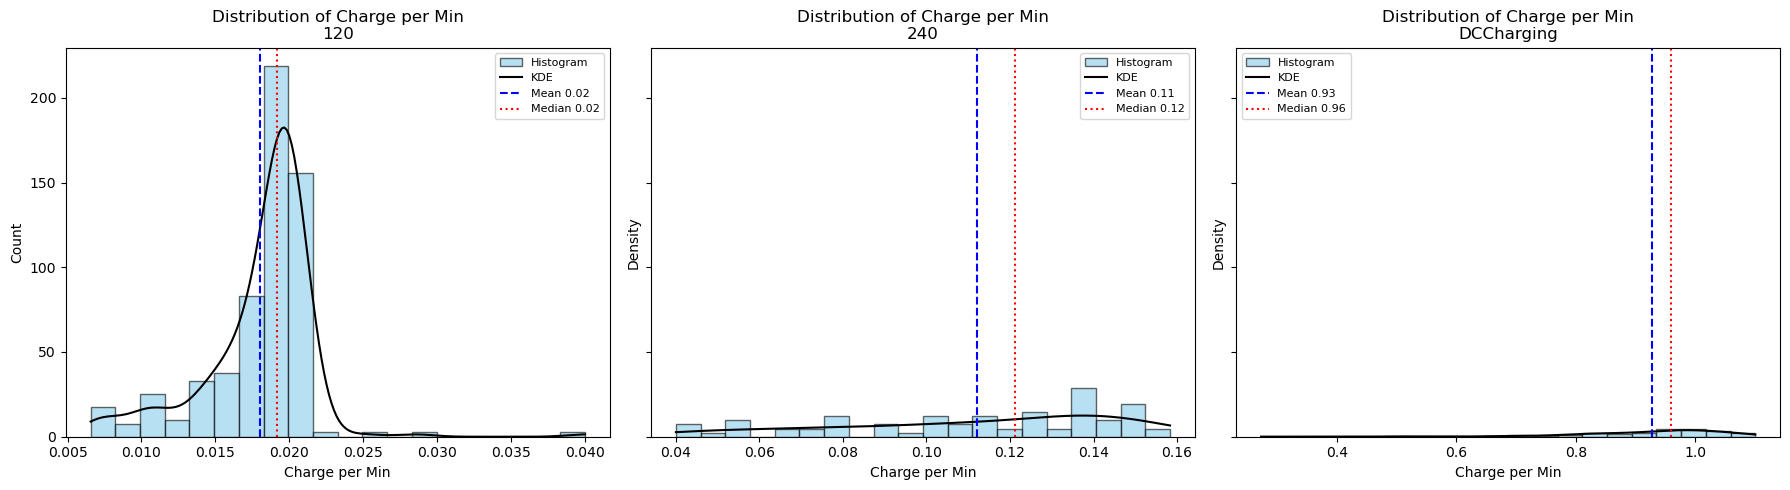

In [27]:
# --- Distribution of Charge per min ---

# Create a figure with 3 subplots, one for each charge_mode
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, mode in enumerate(['120', '240', 'DCCharging']):
    data_mode = charge_data_original.loc[charge_data_original['charge_mode'] == mode, 'charge_per_min']
    ax = axes[i]
    plot_hist_with_kde(data_mode, ax,
                       color='skyblue',
                       title=f"Distribution of Charge per Min\n{mode}",
                       xlabel='Charge per Min')

axes[0].set_ylabel('Count')  # common y-axis label
plt.tight_layout()
plt.show()

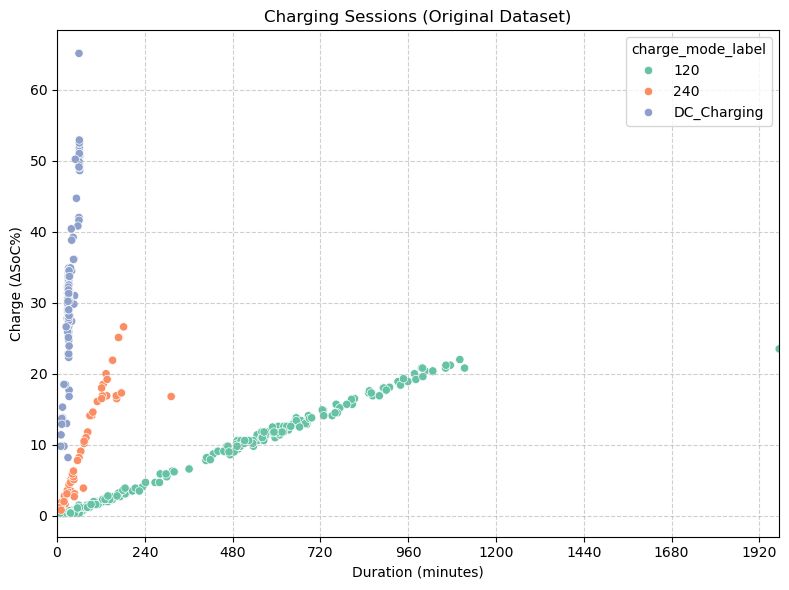

In [28]:
"""
Scatterplot of duration vs. charge,
colored by charge_mode (mapped to labels).
"""
import matplotlib.ticker as mticker

# Mapping of charge_mode
charge_mode_map = {
    '120': "120",
    '240': "240",
    'DCCharging': "DC_Charging"
}

charge_data_original = charge_data_original.copy()
charge_data_original["charge_mode_label"] = charge_data_original["charge_mode"].map(charge_mode_map)

# Define consistent color palette (matching Set2)
fixed_palette = {
    "120": "#66c2a5",       # greenish
    "240": "#fc8d62",       # orange
    "DC_Charging": "#8da0cb" # blue
}

# Define desired order for hues
hue_order = ["120", "240", "DC_Charging"]

# Compute derived features
max_duration = charge_data_original["duration_minutes"].max()
charge_data_original['charge'] = -charge_data_original['discharge']

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=charge_data_original,
    x="duration_minutes",
    y="charge",
    hue="charge_mode_label",
    hue_order=hue_order,     # ← Force order
    palette=fixed_palette,   # ← Consistent colors
    legend="auto"
)

plt.title("Charging Sessions (Original Dataset)")
plt.xlim(0, max_duration)
plt.xlabel("Duration (minutes)")
plt.ylabel("Charge (ΔSoC%)")
plt.grid(True)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(240))
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Post-processing generated data event-level

## Post-process trip data

### Data Inspection and Cleaning

In [29]:
##### Load trip data
trip_data = synthetic_data.copy()

# Add a column id to keep the number of the row
trip_data['id'] = trip_data.index
trip_data = trip_data[trip_data['event'] == 0].reset_index(drop=True)
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event             23970 non-null  int64  
 1   charge_mode       23970 non-null  int64  
 2   duration_minutes  23970 non-null  float64
 3   km_driven         23970 non-null  float64
 4   charge            23970 non-null  float64
 5   id                23970 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 1.1 MB


In [30]:
trip_data.head(10)

,event,charge_mode,duration_minutes,km_driven,charge,id
0,0,0,87.043064,34.433090,-6.613448,0
1,0,0,184.720758,8.347958,6.781767,2
2,0,0,59.385237,33.610928,-8.003572,3
3,0,0,183.677559,141.187825,-25.345530,4
4,0,0,122.274611,79.800379,-15.364420,7
5,0,0,88.017608,56.686774,-12.048375,9
6,0,0,55.043588,31.681835,-5.491861,10
7,0,0,38.416952,8.013869,-0.183275,11
8,0,0,41.463600,22.819437,-4.959156,13
9,0,0,147.888518,102.556719,-20.320904,14


### Data description

In [31]:
# Remove duplicates
init_len = len(trip_data)
trip_data = trip_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(trip_data)}")

Number of duplicates removed: 0


In [32]:
# Check for missing values and print records with them
nan_count = trip_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

records_with_nan = trip_data[trip_data.isna().any(axis=1)]

length = len(records_with_nan)
print(f"\nNumber of records with missing values: {length}\n")
records_with_nan.head(length)

| Features | NaN-counter |
event               0
charge_mode         0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|

Number of records with missing values: 0



,event,charge_mode,duration_minutes,km_driven,charge,id


In [33]:
# main statistics of the dataset
trip_data['delta_soc'] = trip_data['charge']
print("Statistics of the dataset:")
trip_data[['km_driven', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
km_driven,23970.0,36.741003,34.121390,3.460723,13.224226,21.719789,49.459901,202.820402
delta_soc,23970.0,-6.098311,7.020923,-34.006415,-9.743886,-3.670876,-1.011610,9.316977


In [34]:
# Add discharge
trip_data['discharge'] = - trip_data['charge']


# Add avg_speed in km/h 
trip_data['avg_speed'] = np.where(
    trip_data['duration_minutes'] > 0,
    (trip_data['km_driven']) / (trip_data['duration_minutes'] / 60),
    0
)

# Add km_per_perc_of_battery and discharge_per_km 
trip_data['km_per_perc_of_battery'] = trip_data.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)
trip_data['discharge_per_km'] = trip_data.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

# Print statistics
print('Statistics before post-processing\n')
print("Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\nStatistics on discharge:\n", trip_data['discharge'].describe())
print("\nStatistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\nStatistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\nStatistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics before post-processing

Statistics on driven km:
 count    23970.000000
mean        36.741003
std         34.121390
min          3.460723
25%         13.224226
50%         21.719789
75%         49.459901
max        202.820402
Name: km_driven, dtype: float64

Statistics on discharge:
 count    23970.000000
mean         6.098311
std          7.020923
min         -9.316977
25%          1.011610
50%          3.670876
75%          9.743886
max         34.006415
Name: discharge, dtype: float64

Statistics on average speed:
 count    23970.000000
mean        29.272814
std         10.729016
min          2.114435
25%         22.965757
50%         29.234855
75%         37.180813
max         61.117464
Name: avg_speed, dtype: float64
99th percentile of average speed: 50.70 km/h

Statistics on km per percentage of battery:
 count    23970.000000
mean         2.204995
std        586.549143
min     -85154.882603
25%          4.710301
50%          5.457181
75%          7.321424
max      111

### Identify and remove anomalous records

In [35]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
snapshot_records.head(length)

Number of snapshot records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [36]:
# Remove snapshot records
trip_data = trip_data.drop(snapshot_records.index).reset_index(drop=True)

In [37]:
# Identify records with negative duration
negative_duration_records = trip_data[(trip_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
negative_duration_records.head(length)

Number of records with negative duration: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [38]:
# Remove records with negative duration
trip_data = trip_data.drop(negative_duration_records.index).reset_index(drop=True)

In [39]:
# Identify stationary records (data with no changes in soc, odo, but positive duration)
stationary_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary records: {length}")
stationary_records.head(length)

Number of stationary records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [40]:
# Remove stationary records
trip_data = trip_data.drop(stationary_records.index).reset_index(drop=True)

In [41]:
# Identify records with (end_soc) [%] > (soc + 1) [%]   
anomalous_soc_records = trip_data[(trip_data['charge'] > 1)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 1737


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
1,0,0,184.720758,8.347958,6.781767,2,6.781767,-6.781767,2.711539,-1.230941,-0.812386
59,0,0,58.298522,7.043647,1.679290,90,1.679290,-1.679290,7.249220,-4.194420,-0.238412
71,0,0,36.631185,6.211478,1.314294,107,1.314294,-1.314294,10.174081,-4.726094,-0.211591
77,0,0,74.476845,7.237889,4.194249,117,4.194249,-4.194249,5.830985,-1.725670,-0.579485
115,0,0,30.563323,6.994756,1.779269,168,1.779269,-1.779269,13.731666,-3.931252,-0.254372
...,...,...,...,...,...,...,...,...,...,...,...
23842,0,0,47.451284,7.398184,2.584909,34446,2.584909,-2.584909,9.354669,-2.862067,-0.349398
23862,0,0,50.857293,6.125039,1.932748,34475,1.932748,-1.932748,7.226149,-3.169083,-0.315549
23873,0,0,39.017468,11.941904,1.231285,34488,1.231285,-1.231285,18.363934,-9.698735,-0.103106
23909,0,0,48.019117,4.728820,2.399714,34537,2.399714,-2.399714,5.908672,-1.970577,-0.507466


In [42]:
# Remove anomalous soc records
trip_data = trip_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [43]:
# Identify anomalous movement records (end_odo < odo)
anomalous_movement_records = trip_data[(trip_data['km_driven'] < 0)]

length = anomalous_movement_records.shape[0]
print(f"Number of anomalous movement records: {length}")
anomalous_movement_records.head(length)

Number of anomalous movement records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [44]:
# Remove anomalous movement records
trip_data = trip_data.drop(anomalous_movement_records.index).reset_index(drop=True)

In [45]:
# Identify records with high average speed 
anomalous_speed_records = trip_data[(trip_data['avg_speed'] > SPEED_THRESHOLD)]
length = anomalous_speed_records.shape[0]
print(f"Number of records with avg_speed > {SPEED_THRESHOLD} km/h: {length}")
anomalous_speed_records.head(length)

Number of records with avg_speed > 130 km/h: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [46]:
# Remove anomalous speed records
trip_data = trip_data.drop(anomalous_speed_records.index).reset_index(drop=True)

In [47]:
# Identify anomalous records with high discharge per km
anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")
anomalous_discharge_records.head(length)

Number of anomalous discharge records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [48]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [49]:
# Identify anomalous records with low discharge per km
anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] < MIN_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")
anomalous_discharge_records.head(length)

Number of anomalous discharge records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [50]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [51]:
# Identify anomalous records with high km per percentage of battery discharge 
anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")
anomalous_discharge_records.head(length)

Number of anomalous discharge records: 1531


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
21771,0,0,29.102013,11.968152,-0.001069,33918,-0.001069,0.001069,24.674895,11197.799685,0.000089
14887,0,0,26.168106,11.307682,-0.001152,23252,-0.001152,0.001152,25.927017,9815.162376,0.000102
17494,0,0,31.174565,11.796204,-0.001427,27311,-0.001427,0.001427,22.703517,8267.328147,0.000121
2735,0,0,26.778005,11.441470,-0.001435,4226,-0.001435,0.001435,25.636271,7972.189868,0.000125
20051,0,0,31.478409,10.814043,-0.002010,31306,-0.002010,0.002010,20.612305,5380.870765,0.000186
...,...,...,...,...,...,...,...,...,...,...,...
7845,0,0,29.689576,13.887175,-0.693381,12174,-0.693381,0.693381,28.064749,20.028192,0.049930
15993,0,0,39.883358,6.826462,-0.340918,24957,-0.340918,0.340918,10.269640,20.023792,0.049941
6840,0,0,29.108698,13.261636,-0.662347,10567,-0.662347,0.662347,27.335409,20.022173,0.049945
8265,0,0,32.394823,13.034332,-0.651073,12854,-0.651073,0.651073,24.141510,20.019770,0.049951


In [52]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [53]:
# Identify anomalous records with low km per percentage of battery discharge 
anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")
anomalous_discharge_records.head(length)

Number of anomalous discharge records: 1407


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
19027,0,0,56.539640,8.232592,0.821225,31869,0.821225,-0.821225,8.736446,-10.024775,-0.099753
2836,0,0,43.611420,8.868957,0.883817,4704,0.883817,-0.883817,12.201791,-10.034835,-0.099653
7593,0,0,39.496549,8.463054,0.840201,12651,0.840201,-0.840201,12.856396,-10.072651,-0.099279
2545,0,0,41.336094,7.971487,0.789916,4192,0.789916,-0.789916,11.570741,-10.091564,-0.099093
5888,0,0,44.226960,6.128508,0.607035,9744,0.607035,-0.607035,8.314170,-10.095804,-0.099051
...,...,...,...,...,...,...,...,...,...,...,...
6628,0,0,38.219622,13.350250,0.002978,11001,0.002978,-0.002978,20.958214,-4482.936352,-0.000223
20449,0,0,36.912017,15.760959,0.001962,34221,0.001962,-0.001962,25.619233,-8032.498935,-0.000124
19014,0,0,38.102525,11.261179,0.001271,31853,0.001271,-0.001271,17.732965,-8859.904988,-0.000113
2004,0,0,92.162689,13.108676,0.000913,3340,0.000913,-0.000913,8.534045,-14358.182431,-0.000070


In [54]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [55]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19295 entries, 0 to 19294
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   19295 non-null  int64  
 1   charge_mode             19295 non-null  int64  
 2   duration_minutes        19295 non-null  float64
 3   km_driven               19295 non-null  float64
 4   charge                  19295 non-null  float64
 5   id                      19295 non-null  int64  
 6   delta_soc               19295 non-null  float64
 7   discharge               19295 non-null  float64
 8   avg_speed               19295 non-null  float64
 9   km_per_perc_of_battery  19295 non-null  float64
 10  discharge_per_km        19295 non-null  float64
dtypes: float64(8), int64(3)
memory usage: 1.6 MB


In [56]:
# Print statistics
print('Statistics after post-processing\n')
print("Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\nStatistics on discharge:\n", trip_data['discharge'].describe())
print("\nStatistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\nStatistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\nStatistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics after post-processing

Statistics on driven km:
 count    19295.000000
mean        43.007151
std         35.151499
min          3.834627
25%         16.778824
50%         28.572104
75%         60.005495
max        202.820402
Name: km_driven, dtype: float64

Statistics on discharge:
 count    19295.000000
mean         7.792711
std          6.782006
min         -0.999492
25%          2.369010
50%          5.462334
75%         11.703631
max         34.006415
Name: discharge, dtype: float64

Statistics on average speed:
 count    19295.000000
mean        32.425830
std          8.929428
min          4.520277
25%         26.692144
50%         31.887111
75%         39.046196
max         61.117464
Name: avg_speed, dtype: float64
99th percentile of average speed: 51.17 km/h

Statistics on km per percentage of battery:
 count    19295.000000
mean         6.561527
std          3.316957
min         -9.988353
25%          5.017289
50%          5.547573
75%          7.050339
max         1

### Data Visualization and Comparative Analysis

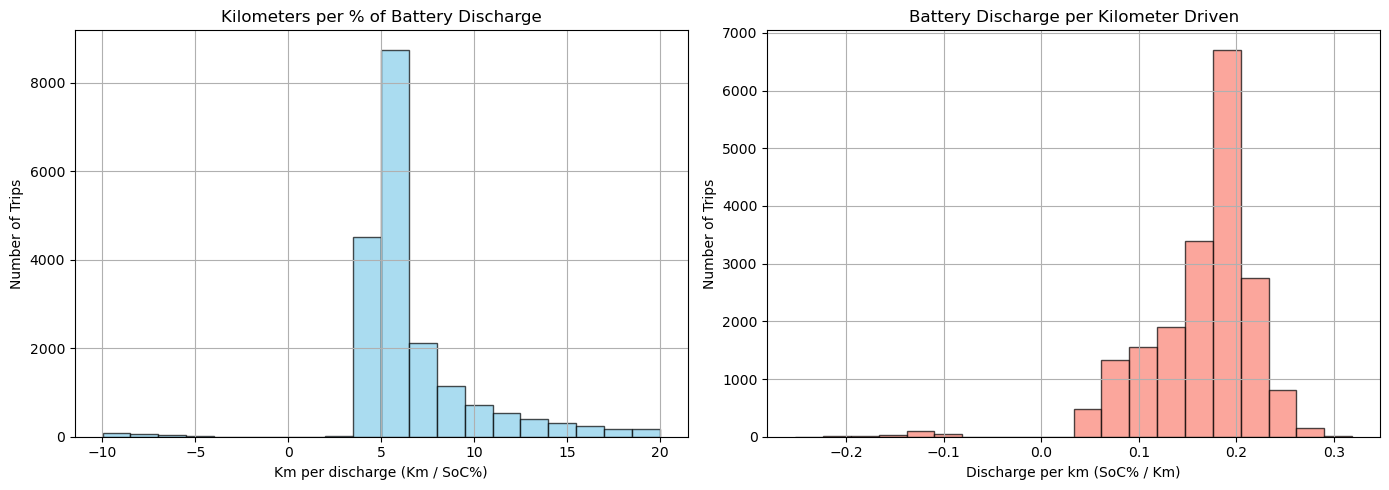

In [57]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kilometers per % battery
axes[0].hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Kilometers per % of Battery Discharge')
axes[0].set_xlabel('Km per discharge (Km / SoC%)')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    trip_data['discharge_per_km'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery Discharge per Kilometer Driven')
axes[1].set_xlabel('Discharge per km (SoC% / Km)')
axes[1].set_ylabel('Number of Trips')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [58]:
trip_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
0,0,0,87.043064,34.433090,-6.613448,0,-6.613448,6.613448,23.735210,5.206526,0.192067
1,0,0,59.385237,33.610928,-8.003572,3,-8.003572,8.003572,33.958872,4.199491,0.238124
2,0,0,183.677559,141.187825,-25.345530,4,-25.345530,25.345530,46.120329,5.570522,0.179516
3,0,0,122.274611,79.800379,-15.364420,7,-15.364420,15.364420,39.157947,5.193843,0.192536
4,0,0,88.017608,56.686774,-12.048375,9,-12.048375,12.048375,38.642341,4.704931,0.212543


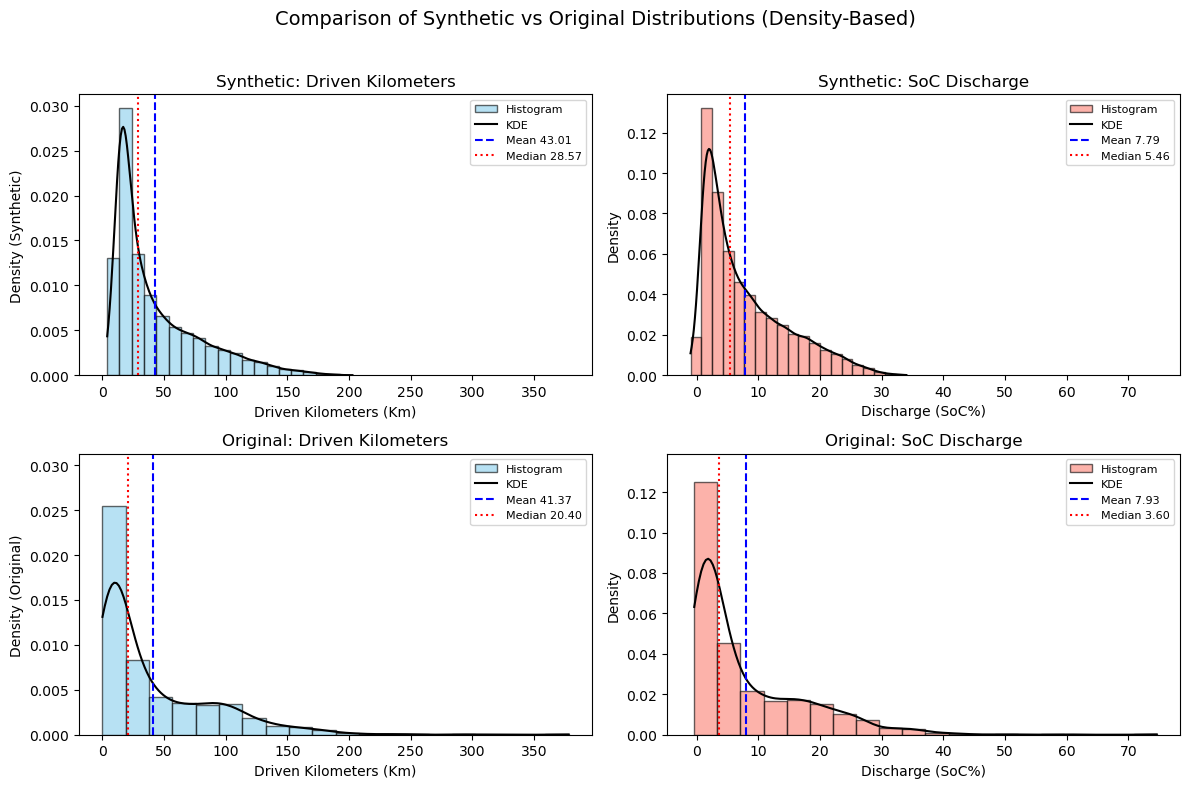

In [59]:
### Visualize comparison between generated and original trip data of main features

# --- Create figure with 2 rows (synthetic on top, original on bottom) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='col')

# Synthetic data (top row)
plot_hist_with_kde(trip_data.get('km_driven', pd.Series(dtype=float)), axes[0, 0],
                   color='skyblue', title='Synthetic: Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data.get('discharge', pd.Series(dtype=float)), axes[0, 1],
                   color='salmon', title='Synthetic: SoC Discharge', xlabel='Discharge (SoC%)')

# Original data (bottom row)
plot_hist_with_kde(trip_data_original.get('km_driven', pd.Series(dtype=float)), axes[1, 0],
                   color='skyblue', title='Original: Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data_original.get('discharge', pd.Series(dtype=float)), axes[1, 1],
                   color='salmon', title='Original: SoC Discharge', xlabel='Discharge (SoC%)')

# --- Match axes scales explicitly between synthetic and original ---
for j in range(2):
    xmin = min(axes[0, j].get_xlim()[0], axes[1, j].get_xlim()[0])
    xmax = max(axes[0, j].get_xlim()[1], axes[1, j].get_xlim()[1])
    ymin = min(axes[0, j].get_ylim()[0], axes[1, j].get_ylim()[0])
    ymax = max(axes[0, j].get_ylim()[1], axes[1, j].get_ylim()[1])
    axes[0, j].set_xlim(xmin, xmax)
    axes[1, j].set_xlim(xmin, xmax)
    axes[0, j].set_ylim(ymin, ymax)
    axes[1, j].set_ylim(ymin, ymax)

# --- Show x-axis tick labels for top plots too ---
for ax in axes[0, :]:
    ax.tick_params(labelbottom=True)

# --- Formatting ---
axes[0, 0].set_ylabel("Density (Synthetic)")
axes[1, 0].set_ylabel("Density (Original)")
fig.suptitle("Comparison of Synthetic vs Original Distributions (Density-Based)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

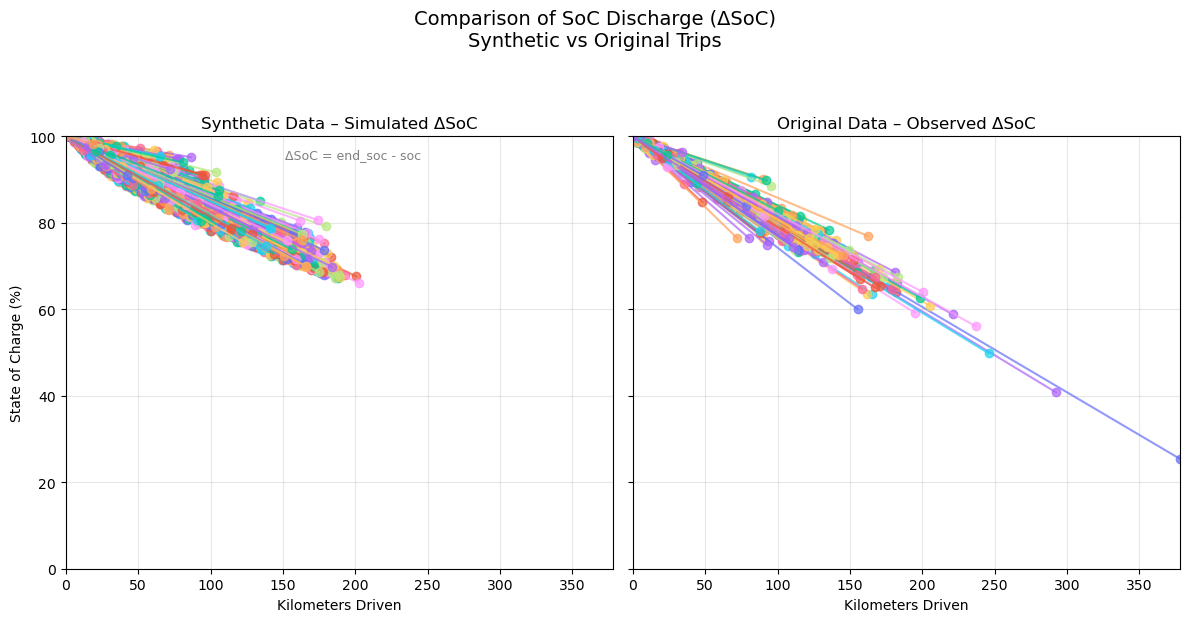

In [60]:
# --- Synthetic data prep ---
trip_data['soc'] = 100
trip_data['end_soc'] = trip_data['soc'] + trip_data['charge']

# --- Shared scales ---
max_km_driven = max(trip_data['km_driven'].max(), trip_data_original['km_driven'].max())

# --- Colors ---
colors = px.colors.qualitative.Plotly

# --- Figure setup ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# ====================================================
# LEFT PANEL – SYNTHETIC
# ====================================================
ax = axes[0]
for i, (_, row) in enumerate(trip_data.iterrows()):
    color = colors[i % len(colors)]
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.7, color=color)

ax.set_title('Synthetic Data – Simulated ΔSoC', fontsize=12)
ax.set_xlabel('Kilometers Driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.text(max_km_driven * 0.4, 95, "ΔSoC = end_soc - soc", fontsize=9, color='gray')

# ====================================================
# RIGHT PANEL – ORIGINAL
# ====================================================
ax = axes[1]
for i, (_, row) in enumerate(trip_data_original.iterrows()):
    color = colors[i % len(colors)]
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.7, color=color)

ax.set_title('Original Data – Observed ΔSoC', fontsize=12)
ax.set_xlabel('Kilometers Driven')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# ====================================================
# SHARED SETTINGS
# ====================================================
# Reverse y-axis for intuitive "battery discharge" visualization
for ax in axes:
    ax.invert_yaxis()

fig.suptitle('Comparison of SoC Discharge (ΔSoC)\nSynthetic vs Original Trips', fontsize=14, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [61]:
trip_data['discharge_per_km'].describe()

count    19295.000000
mean         0.165023
std          0.056184
min         -0.252128
25%          0.139059
50%          0.179474
75%          0.198232
max          0.318555
Name: discharge_per_km, dtype: float64

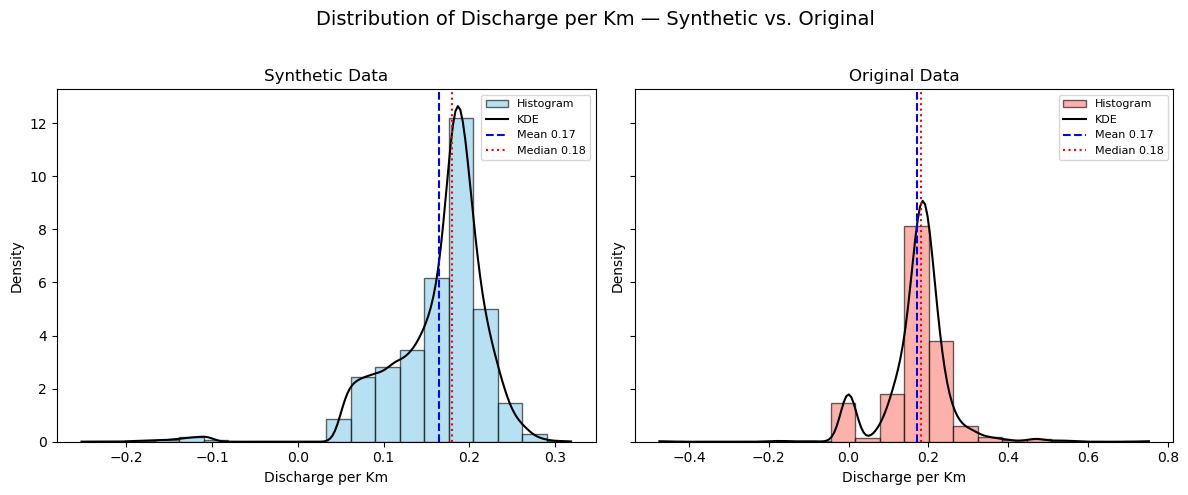

In [62]:
# --- Distribution of Discharge per Km ---
# --- Create side-by-side comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left panel — synthetic data
plot_hist_with_kde(
    trip_data.get('discharge_per_km', pd.Series(dtype=float)),
    axes[0],
    color='skyblue',
    title='Synthetic Data',
    xlabel='Discharge per Km'
)

# Right panel — original data
plot_hist_with_kde(
    trip_data_original.get('discharge_per_km', pd.Series(dtype=float)),
    axes[1],
    color='salmon',
    title='Original Data',
    xlabel='Discharge per Km',
    density=True
)

# --- Styling ---
fig.suptitle('Distribution of Discharge per Km — Synthetic vs. Original', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Save trip data cleaned

In [63]:
# Save DataFrame
if SAVE:
    trip_data.to_csv(file_trip_path_csv, index=False)

In [64]:
trip_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km,soc,end_soc
0,0,0,87.043064,34.433090,-6.613448,0,-6.613448,6.613448,23.735210,5.206526,0.192067,100,93.386552
1,0,0,59.385237,33.610928,-8.003572,3,-8.003572,8.003572,33.958872,4.199491,0.238124,100,91.996428
2,0,0,183.677559,141.187825,-25.345530,4,-25.345530,25.345530,46.120329,5.570522,0.179516,100,74.654470
3,0,0,122.274611,79.800379,-15.364420,7,-15.364420,15.364420,39.157947,5.193843,0.192536,100,84.635580
4,0,0,88.017608,56.686774,-12.048375,9,-12.048375,12.048375,38.642341,4.704931,0.212543,100,87.951625


In [65]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19295 entries, 0 to 19294
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   19295 non-null  int64  
 1   charge_mode             19295 non-null  int64  
 2   duration_minutes        19295 non-null  float64
 3   km_driven               19295 non-null  float64
 4   charge                  19295 non-null  float64
 5   id                      19295 non-null  int64  
 6   delta_soc               19295 non-null  float64
 7   discharge               19295 non-null  float64
 8   avg_speed               19295 non-null  float64
 9   km_per_perc_of_battery  19295 non-null  float64
 10  discharge_per_km        19295 non-null  float64
 11  soc                     19295 non-null  int64  
 12  end_soc                 19295 non-null  float64
dtypes: float64(9), int64(4)
memory usage: 1.9 MB


## Post-process charge data

### Data Inspection and Cleaning

In [66]:
#### Load charge data
charge_data = synthetic_data.copy()

# Add a column id to keep the number of the row
charge_data['id'] = charge_data.index
charge_data = charge_data[charge_data['event'] == 1].reset_index(drop=True)
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10650 entries, 0 to 10649
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event             10650 non-null  int64  
 1   charge_mode       10650 non-null  int64  
 2   duration_minutes  10650 non-null  float64
 3   km_driven         10650 non-null  float64
 4   charge            10650 non-null  float64
 5   id                10650 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 499.3 KB


In [67]:
charge_data.head(10)

,event,charge_mode,duration_minutes,km_driven,charge,id
0,1,1,279.628437,4.556972,8.360581,1
1,1,3,87.369400,3.288001,21.223432,5
2,1,1,390.359651,3.966179,9.691548,6
3,1,2,65.202594,3.026088,10.575335,8
4,1,2,122.070420,2.110100,8.619843,12
5,1,2,126.893595,2.593315,9.557879,15
6,1,2,112.235132,2.325306,8.154052,16
7,1,1,305.591962,7.238080,8.733595,19
8,1,1,75.507484,8.108176,6.808971,20
9,1,1,81.200141,2.447691,2.923168,25


### Data description

In [68]:
# Remove duplicates
init_len = len(charge_data)
charge_data = charge_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(charge_data)}")

Number of duplicates removed: 0


In [69]:
# Check for missing values and print records with them
nan_count = charge_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")



records_with_nan = charge_data[charge_data.isna().any(axis=1)]

length = len(records_with_nan)
print(f"\nNumber of records with missing values: {length}\n")
records_with_nan.head(length)

| Features | NaN-counter |
event               0
charge_mode         0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|

Number of records with missing values: 0



,event,charge_mode,duration_minutes,km_driven,charge,id


In [70]:
# main statistics of the dataset
charge_data['delta_soc'] = charge_data['charge']
print("Statistics of the dataset:")
charge_data[['duration_minutes', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
duration_minutes,10650.0,157.928913,170.462930,38.779395,56.836790,83.862876,173.363447,1037.378768
delta_soc,10650.0,12.831704,9.375077,-1.101418,5.753124,9.951181,17.119465,37.326545


In [71]:
# Add min_per_perc_of_battery and charge_per_min
charge_data['min_per_perc_of_battery'] = charge_data.apply(
    lambda row: row['duration_minutes'] / row['charge'] if row['charge'] != 0 else 0,
    axis=1
)

charge_data['charge_per_min'] = charge_data.apply(
    lambda row: row['charge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)

#Print statistics
print('Statistics before post-processing')
print("\nStatistics on charge:\n", charge_data['charge'].describe())
print("\nStatistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\nStatistics on charge_per_min:\n", charge_data['charge_per_min'].describe())

Statistics before post-processing

Statistics on charge:
 count    10650.000000
mean        12.831704
std          9.375077
min         -1.101418
25%          5.753124
50%          9.951181
75%         17.119465
max         37.326545
Name: charge, dtype: float64

Statistics on min_per_perc_of_battery:
 count    10650.000000
mean        18.914347
std         47.231823
min      -2751.055139
25%          4.029911
50%         16.337686
75%         28.862192
max       2589.464306
Name: min_per_perc_of_battery, dtype: float64

Statistics on charge_per_min:
 count    10650.000000
mean         0.175487
std          0.212412
min         -0.016432
25%          0.034567
50%          0.060864
75%          0.246891
max          0.923997
Name: charge_per_min, dtype: float64


### Identify and remove anomalous record

In [72]:
# Identify records with negative duration
negative_duration_records = charge_data[(charge_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
negative_duration_records.head(length)

Number of records with negative duration: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [73]:
# Remove records with negative duration
charge_data = charge_data.drop(negative_duration_records.index).reset_index(drop=True)

In [74]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = charge_data[(charge_data['charge'] == 0) & (charge_data['km_driven'] == 0) & (charge_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
snapshot_records.head(length)

Number of snapshot records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [75]:
# Remove snapshot records
charge_data = charge_data.drop(snapshot_records.index).reset_index(drop=True)

In [76]:
# Identify stationary records (data with no changes in soc, but positive duration)
stationary_records = charge_data[(charge_data['charge'] == 0) & (charge_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary rows: {length}")
stationary_records.head(length)

Number of stationary rows: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [77]:
# Remove stationary records
charge_data = charge_data.drop(stationary_records.index).reset_index(drop=True)

In [78]:
# Identify records with end_soc [%] < soc [%]   
anomalous_soc_records = charge_data[(charge_data['charge'] < 0)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 14


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
71,1,0,56.065042,4.334078,-0.543483,244,-0.543483,-103.158807,-0.009694
103,1,0,59.389134,4.652613,-0.196365,329,-0.196365,-302.442823,-0.003306
330,1,0,56.789689,4.231254,-0.140700,1071,-0.140700,-403.621425,-0.002478
466,1,0,56.004642,5.357590,-0.245026,1503,-0.245026,-228.565682,-0.004375
1367,1,0,59.243350,5.938997,-0.664379,4458,-0.664379,-89.170989,-0.011214
1524,1,0,48.745723,5.214237,-0.338328,4911,-0.338328,-144.078337,-0.006941
1967,1,0,73.736936,10.108203,-0.318344,6380,-0.318344,-231.626832,-0.004317
2638,1,0,51.198105,6.611427,-0.026057,8689,-0.026057,-1964.818038,-0.000509
3593,1,0,96.402507,5.548851,-0.035042,11677,-0.035042,-2751.055139,-0.000363
7906,1,0,50.357093,4.734424,-0.565815,25553,-0.565815,-88.999181,-0.011236


In [79]:
# Remove anomalous soc records
charge_data = charge_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [80]:
# Identify records with high charge per minute
anomalous_charge_records = charge_data[(charge_data['charge_per_min'] > MAX_CHARGE_PER_MIN)]
length = anomalous_charge_records.shape[0]
print(f"Number of records with charge per minute > {MAX_CHARGE_PER_MIN}: {length}")
anomalous_charge_records.head(length)

Number of records with charge per minute > 1.1: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [81]:
# Remove anomalous charge records
charge_data = charge_data.drop(anomalous_charge_records.index).reset_index(drop=True)

In [82]:
# Identify records with low charge per minute
anomalous_charge_records = charge_data[(charge_data['charge_per_min'] < MIN_CHARGE_PER_MIN)]
length = anomalous_charge_records.shape[0]
print(f"Number of records with charge per minute < {MIN_CHARGE_PER_MIN}: {length}")
anomalous_charge_records.head(length)

Number of records with charge per minute < 0.005: 9


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
1553,1,0,95.972984,8.921076,0.287770,5020,0.287770,333.505678,0.002998
2142,1,1,57.132133,5.847861,0.187816,6978,0.187816,304.192645,0.003287
3024,1,1,89.839993,8.667433,0.090734,10000,0.090734,990.148783,0.001010
5722,1,0,63.985362,4.034089,0.300510,18624,0.300510,212.922486,0.004697
6169,1,0,47.820842,4.717087,0.177415,20013,0.177415,269.541516,0.003710
7096,1,0,49.281093,6.152073,0.074105,22969,0.074105,665.014643,0.001504
7140,1,0,118.323860,9.582689,0.045694,23120,0.045694,2589.464306,0.000386
10257,1,0,104.850575,7.986972,0.266071,33320,0.266071,394.070494,0.002538
10269,1,0,50.849833,4.765260,0.232913,33373,0.232913,218.320761,0.004580


In [83]:
# Remove anomalous charge records
charge_data = charge_data.drop(anomalous_charge_records.index).reset_index(drop=True)

In [84]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10627 entries, 0 to 10626
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    10627 non-null  int64  
 1   charge_mode              10627 non-null  int64  
 2   duration_minutes         10627 non-null  float64
 3   km_driven                10627 non-null  float64
 4   charge                   10627 non-null  float64
 5   id                       10627 non-null  int64  
 6   delta_soc                10627 non-null  float64
 7   min_per_perc_of_battery  10627 non-null  float64
 8   charge_per_min           10627 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 747.3 KB


In [85]:
#Print statistics
print('Statistics after post-processing')
print("\nStatistics on charge:\n", charge_data['charge'].describe())
print("\nStatistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\nStatistics on charge_per_min:\n", charge_data['charge_per_min'].describe())

Statistics after post-processing

Statistics on charge:
 count    10627.000000
mean        12.859801
std          9.365706
min          0.274223
25%          5.775232
50%          9.969296
75%         17.148607
max         37.326545
Name: charge, dtype: float64

Statistics on min_per_perc_of_battery:
 count    10627.000000
mean        19.046840
std         17.072405
min          1.082254
25%          4.041935
50%         16.353446
75%         28.829704
max        199.467329
Name: min_per_perc_of_battery, dtype: float64

Statistics on charge_per_min:
 count    10627.000000
mean         0.175873
std          0.212479
min          0.005013
25%          0.034686
50%          0.061149
75%          0.247406
max          0.923997
Name: charge_per_min, dtype: float64


### Charge_mode re-assignment

In [86]:
# Print max charge_data_original['charge_per_min'] 
print(charge_data.groupby("charge_mode")["charge_per_min"].max())

charge_mode
0    0.074777
1    0.187518
2    0.406562
3    0.923997
Name: charge_per_min, dtype: float64


In [87]:
if REASSIGN_CHARGE_MODE:

    max_120 = float(max_charge_mode_per_minute.get('120', np.nan))
    max_240 = float(max_charge_mode_per_minute.get('240', np.nan))

    # If one is missing, replace with a safe number
    # - If max_120 missing → treat everything as > max_120
    # - If max_240 missing → treat everything > max_120 as mode 3
    if np.isnan(max_120):
        max_120 = -np.inf   # nothing ≤ max_120
    if np.isnan(max_240):
        max_240 = np.inf    # everything ≤ max_240 if needed

    conditions = [
        charge_data['charge_per_min'] <= max_120,
        (charge_data['charge_per_min'] > max_120) & (charge_data['charge_per_min'] <= max_240)
    ]

    values = [1, 2]

    charge_data['charge_mode'] = np.select(conditions, values, default=3)


### Data Visualization and Comparative Analysis

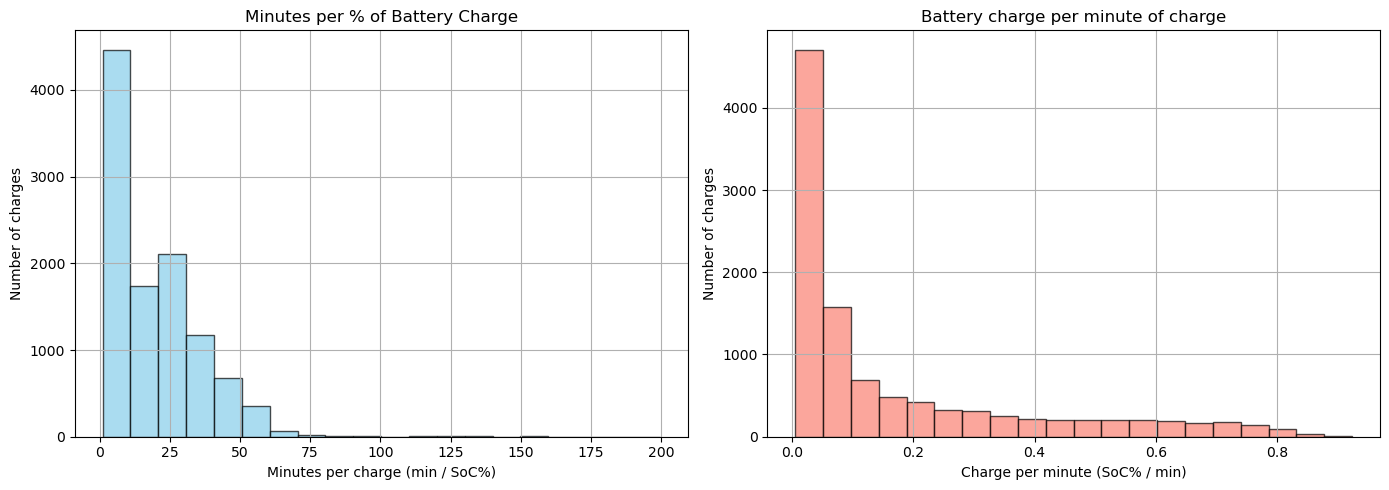

In [88]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Minutes per % battery
axes[0].hist(
    charge_data['min_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Minutes per % of Battery Charge')
axes[0].set_xlabel('Minutes per charge (min / SoC%)')
axes[0].set_ylabel('Number of charges')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    charge_data['charge_per_min'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery charge per minute of charge')
axes[1].set_xlabel('Charge per minute (SoC% / min)')
axes[1].set_ylabel('Number of charges')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [89]:
charge_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
0,1,1,279.628437,4.556972,8.360581,1,8.360581,33.446054,0.029899
1,1,3,87.369400,3.288001,21.223432,5,21.223432,4.116648,0.242916
2,1,1,390.359651,3.966179,9.691548,6,9.691548,40.278358,0.024827
3,1,3,65.202594,3.026088,10.575335,8,10.575335,6.165535,0.162192
4,1,2,122.070420,2.110100,8.619843,12,8.619843,14.161559,0.070614


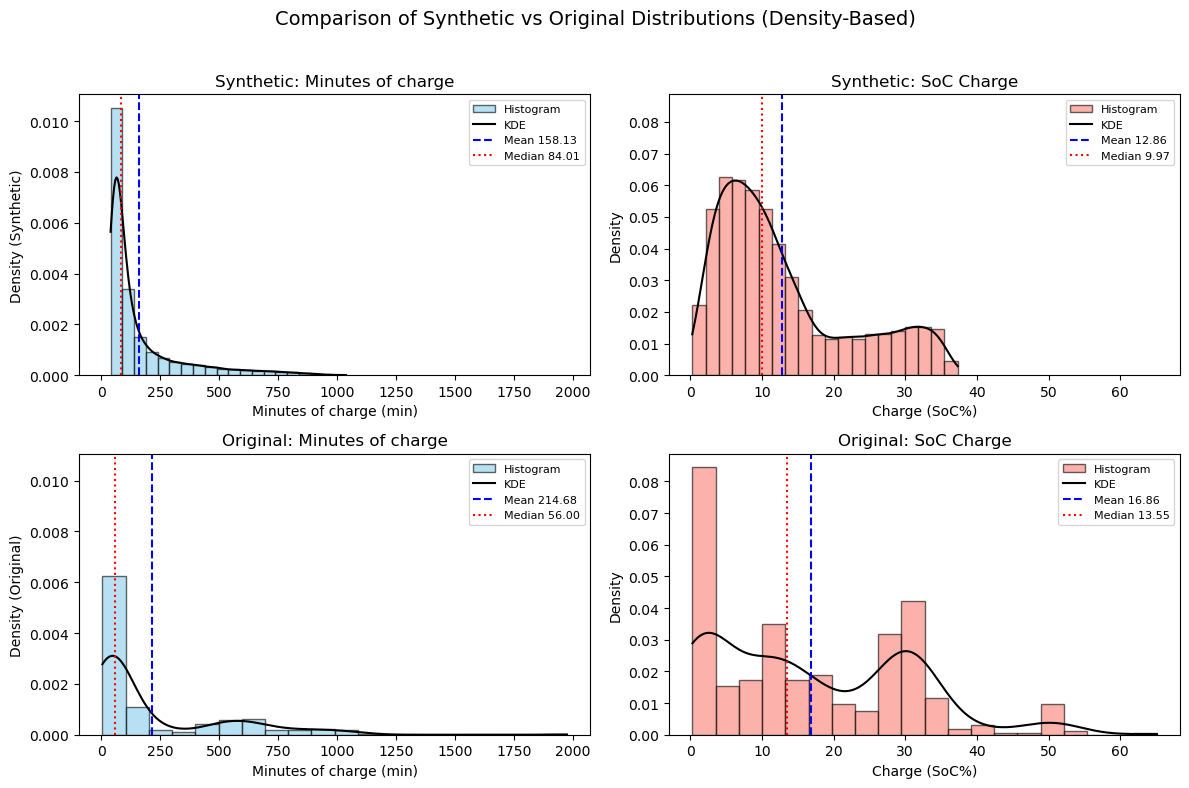

In [90]:
# --- Create figure with 2 rows (synthetic on top, original on bottom) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='col')

# Synthetic data (top row)
plot_hist_with_kde(charge_data.get('duration_minutes', pd.Series(dtype=float)), axes[0, 0],
                   color='skyblue', title='Synthetic: Minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(charge_data.get('charge', pd.Series(dtype=float)), axes[0, 1],
                   color='salmon', title='Synthetic: SoC Charge', xlabel='Charge (SoC%)')

# Original data (bottom row)
plot_hist_with_kde(charge_data_original.get('duration_minutes', pd.Series(dtype=float)), axes[1, 0],
                   color='skyblue', title='Original: Minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(charge_data_original.get('charge', pd.Series(dtype=float)), axes[1, 1],
                   color='salmon', title='Original: SoC Charge', xlabel='Charge (SoC%)')

# --- Match axes scales explicitly between synthetic and original ---
for j in range(2):
    xmin = min(axes[0, j].get_xlim()[0], axes[1, j].get_xlim()[0])
    xmax = max(axes[0, j].get_xlim()[1], axes[1, j].get_xlim()[1])
    ymin = min(axes[0, j].get_ylim()[0], axes[1, j].get_ylim()[0])
    ymax = max(axes[0, j].get_ylim()[1], axes[1, j].get_ylim()[1])
    axes[0, j].set_xlim(xmin, xmax)
    axes[1, j].set_xlim(xmin, xmax)
    axes[0, j].set_ylim(ymin, ymax)
    axes[1, j].set_ylim(ymin, ymax)

# --- Show x-axis tick labels for top plots too ---
for ax in axes[0, :]:
    ax.tick_params(labelbottom=True)

# --- Formatting ---
axes[0, 0].set_ylabel("Density (Synthetic)")
axes[1, 0].set_ylabel("Density (Original)")
fig.suptitle("Comparison of Synthetic vs Original Distributions (Density-Based)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

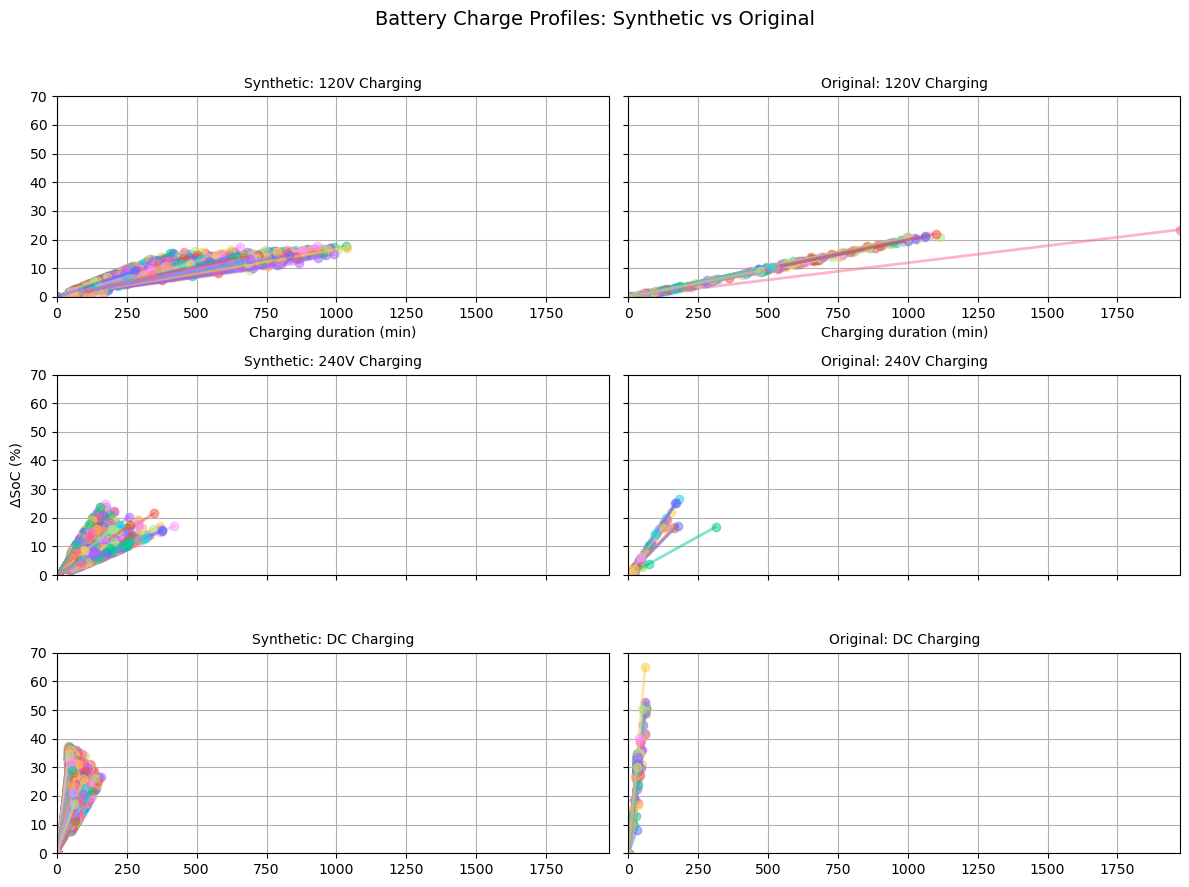

In [91]:
# --- Synthetic data prep ---
charge_data = charge_data.copy()
charge_data['delta_soc'] = charge_data['charge']  # already ΔSoC
charge_data['soc'] = 0
charge_data['end_soc'] = charge_data['delta_soc']

# --- Original data prep ---
charge_data_original = charge_data_original.copy()
charge_data_original['delta_soc'] = (
    charge_data_original['end_soc'] - charge_data_original['soc']
)
charge_data_original['soc'] = 0
charge_data_original['end_soc'] = charge_data_original['delta_soc']

# --- Shared scales ---
max_minutes = max(
    charge_data['duration_minutes'].max(),
    charge_data_original['duration_minutes'].max()
)
max_soc = 70  # y-limit

# --- Colors ---
colors = px.colors.qualitative.Plotly
n_colors = len(colors)

# --- Mode mapping ---
mode_titles = {
    '120': ('Synthetic: 120V Charging', 'Original: 120V Charging'),
    '240': ('Synthetic: 240V Charging', 'Original: 240V Charging'),
    'DC':  ('Synthetic: DC Charging', 'Original: DC Charging')
}

# --- Figure setup ---
fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(12, 9),
    sharex=True, sharey=True
)

# --- Loop through modes ---
for i, (key, (title_syn, title_orig)) in enumerate(mode_titles.items()):

    # --- Filter synthetic (numeric codes) ---
    if key == 'DC':
        syn = charge_data[charge_data['charge_mode'] == 3]
    elif key == '120':
        syn = charge_data[charge_data['charge_mode'] == 1]
    elif key == '240':
        syn = charge_data[charge_data['charge_mode'] == 2]

    # --- Filter original (string-based modes) ---
    if key == 'DC':
        orig = charge_data_original[
            charge_data_original['charge_mode'].astype(str).str.contains('DC', case=False, na=False)
        ]
    else:
        orig = charge_data_original[
            charge_data_original['charge_mode'].astype(str).str.contains(key, case=False, na=False)
        ]

    # --- LEFT: Synthetic ---
    ax_syn = axes[i, 0]
    for j, (_, row) in enumerate(syn.iterrows()):
        ax_syn.plot(
            [0, row['duration_minutes']],
            [0, row['end_soc']],  # always start from 0
            marker='o',
            alpha=0.5,
            color=colors[j % n_colors],
            linewidth=2
        )
    ax_syn.set_title(title_syn, fontsize=10)
    ax_syn.grid(True)
    ax_syn.set_xlim(0, max_minutes)
    ax_syn.set_ylim(0, max_soc)
    if i == 1:
        ax_syn.set_ylabel("ΔSoC (%)")

    # --- RIGHT: Original ---
    ax_orig = axes[i, 1]
    for j, (_, row) in enumerate(orig.iterrows()):
        ax_orig.plot(
            [0, row['duration_minutes']],
            [0, row['end_soc']],  # always start from 0
            marker='o',
            alpha=0.5,
            color=colors[j % n_colors],
            linewidth=2
        )
    ax_orig.set_title(title_orig, fontsize=10)
    ax_orig.grid(True)
    ax_orig.set_xlim(0, max_minutes)
    ax_orig.set_ylim(0, max_soc)

# --- Shared ----
for ax in axes[0, :]:
    ax.set_xlabel("Charging duration (min)")
    ax.tick_params(labelbottom=True)

fig.suptitle("Battery Charge Profiles: Synthetic vs Original", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [92]:
charge_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min,soc,end_soc
0,1,1,279.628437,4.556972,8.360581,1,8.360581,33.446054,0.029899,0,8.360581
1,1,3,87.369400,3.288001,21.223432,5,21.223432,4.116648,0.242916,0,21.223432
2,1,1,390.359651,3.966179,9.691548,6,9.691548,40.278358,0.024827,0,9.691548
3,1,3,65.202594,3.026088,10.575335,8,10.575335,6.165535,0.162192,0,10.575335
4,1,2,122.070420,2.110100,8.619843,12,8.619843,14.161559,0.070614,0,8.619843


In [93]:
charge_data['charge_per_min'].describe()

count    10627.000000
mean         0.175873
std          0.212479
min          0.005013
25%          0.034686
50%          0.061149
75%          0.247406
max          0.923997
Name: charge_per_min, dtype: float64

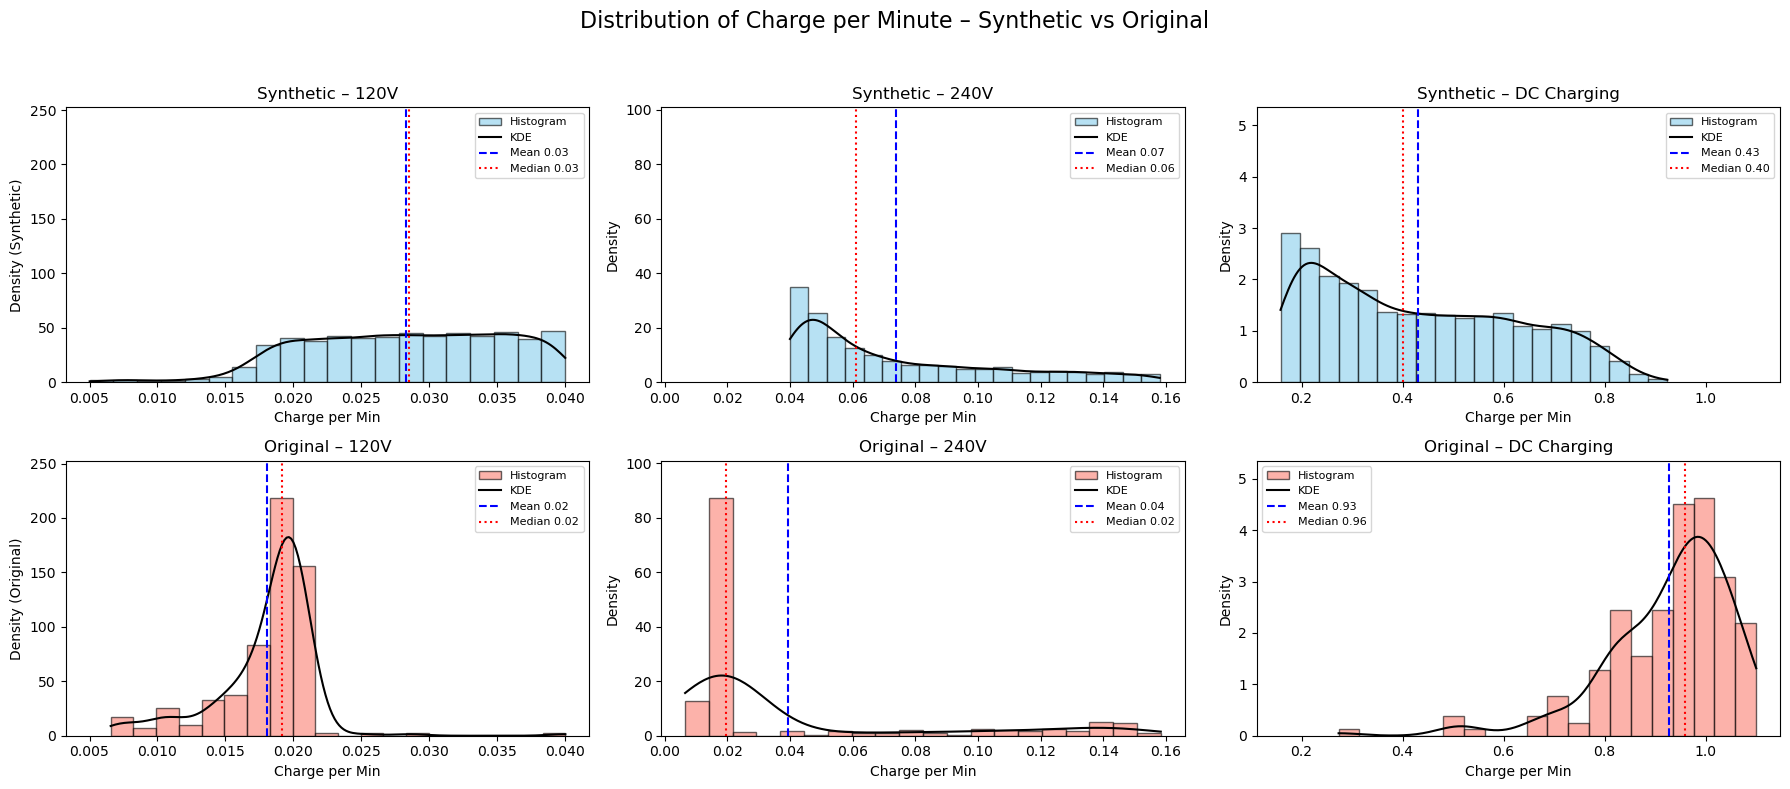

In [94]:
# --- Distribution of Charge per Min: Synthetic vs Original ---

# Map charge_mode values to labels
charge_labels = {1: "120V", 2: "240V", 3: "DC Charging"}

# Figure setup: 2 rows (synthetic/original) × 3 columns (charge modes)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))  # no sharex or sharey now

for i, mode in enumerate([1, 2, 3]):
    # --- Synthetic ---
    data_syn = charge_data.loc[charge_data['charge_mode'] == mode, 'charge_per_min']
    ax_syn = axes[0, i]
    plot_hist_with_kde(
        data_syn,
        ax=ax_syn,
        color='skyblue',
        title=f"Synthetic – {charge_labels[mode]}",
        xlabel='Charge per Min'
    )

    # --- Original ---
    if mode == 3:
        mask_orig = charge_data_original['charge_mode'].astype(str).str.contains('DC', case=False, na=False)
    else:
        mask_orig = charge_data_original['charge_mode'].astype(str).str.contains(str(mode), case=False, na=False)
    data_orig = charge_data_original.loc[mask_orig, 'charge_per_min']

    ax_orig = axes[1, i]
    plot_hist_with_kde(
        data_orig,
        ax=ax_orig,
        color='salmon',
        title=f"Original – {charge_labels[mode]}",
        xlabel='Charge per Min'
    )

    # --- Smart x-axis per column ---
    all_data = pd.concat([data_syn, data_orig]).dropna()
    if not all_data.empty:
        xmin, xmax = all_data.min(), all_data.max()
        xmargin = (xmax - xmin) * 0.05
        ax_syn.set_xlim(xmin - xmargin, xmax + xmargin)
        ax_orig.set_xlim(xmin - xmargin, xmax + xmargin)

    # --- Smart y-axis per column ---
    ymax_vals = [ax_syn.get_ylim()[1], ax_orig.get_ylim()[1]]
    ymax = max(ymax_vals) * 1.1  # 10% padding
    ax_syn.set_ylim(0, ymax)
    ax_orig.set_ylim(0, ymax)

# --- Common labels ---
axes[0, 0].set_ylabel('Density (Synthetic)')
axes[1, 0].set_ylabel('Density (Original)')

fig.suptitle("Distribution of Charge per Minute – Synthetic vs Original", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

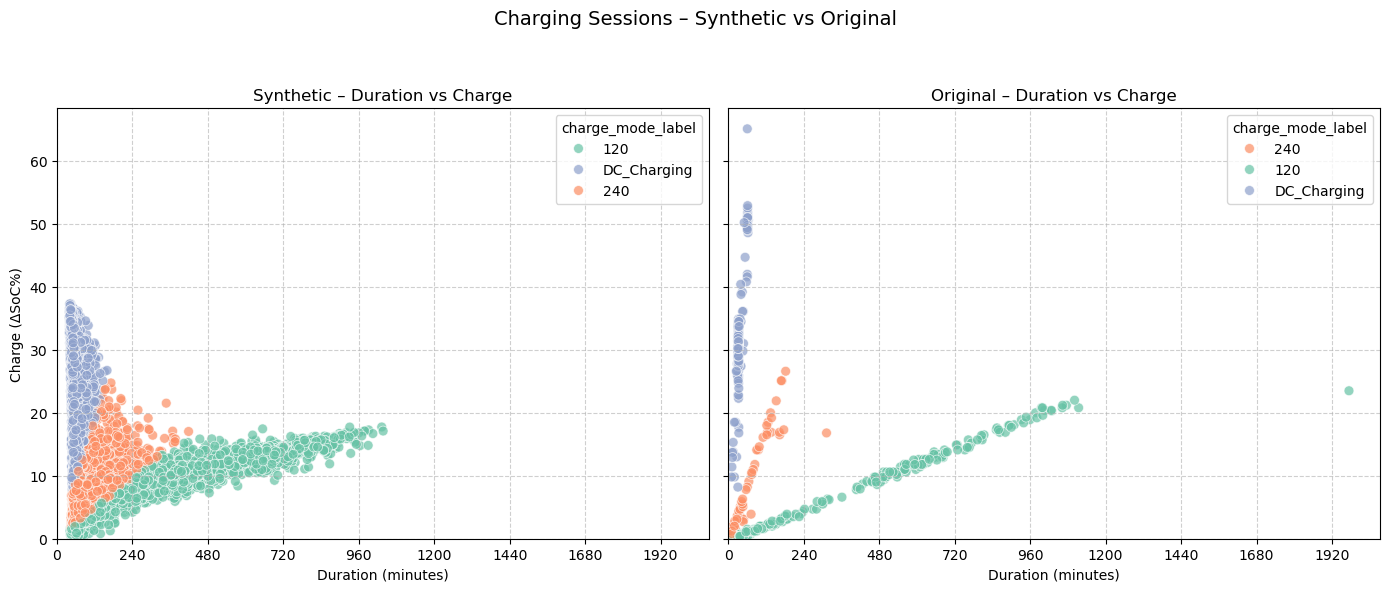

In [95]:
# --- Copy to avoid modifying originals ---
charge_data_syn = charge_data.copy()
charge_data_orig = charge_data_original.copy()

# --- Normalize charge_mode labels for consistency ---
def normalize_label_syn(val):
    if val == 1:
        return '120'
    elif val == 2:
        return '240'
    elif val == 3:
        return 'DC_Charging'
    else:
        return None

def normalize_label_orig(val):
    s = str(val).strip().lower()
    if 'dc' in s:
        return 'DC_Charging'
    elif '120' in s:
        return '120'
    elif '240' in s:
        return '240'
    else:
        return None

charge_data_syn['charge_mode_label'] = charge_data_syn['charge_mode'].apply(normalize_label_syn)
charge_data_orig['charge_mode_label'] = charge_data_orig['charge_mode'].apply(normalize_label_orig)

# --- Define consistent color palette ---
fixed_palette = {
    "120": "#66c2a5",        # greenish
    "240": "#fc8d62",        # orange
    "DC_Charging": "#8da0cb" # blue
}

# --- Shared axis limits for fair comparison ---
max_duration = max(
    charge_data_syn['duration_minutes'].max(),
    charge_data_orig['duration_minutes'].max()
)
max_charge = max(
    charge_data_syn['charge'].max(),
    charge_data_orig['charge'].max()
)

# --- Create side-by-side subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# ==========================================================
# LEFT: Synthetic
# ==========================================================
sns.scatterplot(
    data=charge_data_syn,
    x='duration_minutes',
    y='charge',
    hue='charge_mode_label',
    palette=fixed_palette,
    s=50,
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("Synthetic – Duration vs Charge", fontsize=12)
axes[0].set_xlim(0, max_duration * 1.05)
axes[0].set_ylim(0, max_charge * 1.05)
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Charge (ΔSoC%)")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(60))

# ==========================================================
# RIGHT: Original
# ==========================================================
sns.scatterplot(
    data=charge_data_orig,
    x='duration_minutes',
    y='charge',
    hue='charge_mode_label',
    palette=fixed_palette,
    s=50,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("Original – Duration vs Charge", fontsize=12)
axes[1].set_xlim(0, max_duration * 1.05)
axes[1].set_ylim(0, max_charge * 1.05)
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(240))



# --- Final layout ---
fig.suptitle("Charging Sessions – Synthetic vs Original", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [96]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10627 entries, 0 to 10626
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    10627 non-null  int64  
 1   charge_mode              10627 non-null  int64  
 2   duration_minutes         10627 non-null  float64
 3   km_driven                10627 non-null  float64
 4   charge                   10627 non-null  float64
 5   id                       10627 non-null  int64  
 6   delta_soc                10627 non-null  float64
 7   min_per_perc_of_battery  10627 non-null  float64
 8   charge_per_min           10627 non-null  float64
 9   soc                      10627 non-null  int64  
 10  end_soc                  10627 non-null  float64
dtypes: float64(7), int64(4)
memory usage: 913.4 KB


### Save charge data cleaned

In [97]:
if SAVE:
    # Save DataFrame
    charge_data.to_csv(file_charge_path_csv, index=False)

# Save cleaned dataset

In [98]:
if SAVE:
    # Take raw generated data
    data = synthetic_data.copy()
    
    # load also trip_data and charge_data and then filter data, keeping only rows present in trip_data and charge_data
    
    trip_data_cleaned = pd.read_csv(file_trip_path_csv) 
    
    #take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
    trip_data_cleaned = trip_data_cleaned[['id']]
    charge_data_cleaned = pd.read_csv(file_charge_path_csv)
    
    # take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
    charge_data_cleaned = charge_data_cleaned[[ 'id']]
    
    
    # keep rows that are present in ids of trip_data and charge_data
    data['id'] = data.index
    
    data = data[data['id'].isin(trip_data_cleaned['id']) | data['id'].isin(charge_data_cleaned['id'])]
    
    #drop columns 'id'
    data = data.drop(columns=['id'])
    
    #when event = 1 --> set end_odo = odo 
    #data.loc[data['event'] == 1, 'end_odo'] = data['odo']
    data.loc[data['event'] == 1, 'km_driven'] = 0
    
    # add in first position column 'vin', all rows with value -2.47174E+18 or -1.12313E+18
    #data.insert(0, 'vin', -2.47174E+18)
    
    # map event 0 -> trip, 1 -> charge
    data['event'] = data['event'].map({0: 'trip', 1: 'charge'})
    
    # map charge_mode 1 -> 120, 2 -> 240, 3 -> DC Charging
    data['charge_mode'] = data['charge_mode'].map({0: 0, 1: 120, 2: 240, 3: 'DC Charging'})
    data.to_csv(file_cleaned_path_csv, index=False)